In [11]:
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch.nn.functional as F

import numpy as np
import pandas as pd
from scipy.ndimage import label

from scipy.stats import levy_stable

In [4]:
global colorsNw
colorsNw = {
    "gray": {
        0: "#f8f9fa",
        1: "#f1f3f5",
        2: "#e9ecef",
        3: "#dee2e6",
        4: "#ced4da",
        5: "#adb5bd",
        6: "#868e96",
        7: "#495057",
        8: "#343a40",
        9: "#212529",
    },
    "red": {
        0: "#fff5f5",
        1: "#ffe3e3",
        2: "#ffc9c9",
        3: "#ffa8a8",
        4: "#ff8787",
        5: "#ff6b6b",
        6: "#fa5252",
        7: "#f03e3e",
        8: "#e03131",
        9: "#c92a2a",
    },
    "pink": {
        0: "#fff0f6",
        1: "#ffdeeb",
        2: "#fcc2d7",
        3: "#faa2c1",
        4: "#f783ac",
        5: "#f06595",
        6: "#e64980",
        7: "#d6336c",
        8: "#c2255c",
        9: "#a61e4d",
    },
    "grape": {
        0: "#f8f0fc",
        1: "#f3d9fa",
        2: "#eebefa",
        3: "#e599f7",
        4: "#da77f2",
        5: "#cc5de8",
        6: "#be4bdb",
        7: "#ae3ec9",
        8: "#9c36b5",
        9: "#862e9c",
    },
    "violet": {
        0: "#f3f0ff",
        1: "#e5dbff",
        2: "#d0bfff",
        3: "#b197fc",
        4: "#9775fa",
        5: "#845ef7",
        6: "#7950f2",
        7: "#7048e8",
        8: "#6741d9",
        9: "#5f3dc4",
    },
    "indigo": {
        0: "#edf2ff",
        1: "#dbe4ff",
        2: "#bac8ff",
        3: "#91a7ff",
        4: "#748ffc",
        5: "#5c7cfa",
        6: "#4c6ef5",
        7: "#4263eb",
        8: "#3b5bdb",
        9: "#364fc7",
    },
    "blue": {
        0: "#e7f5ff",
        1: "#d0ebff",
        2: "#a5d8ff",
        3: "#74c0fc",
        4: "#4dabf7",
        5: "#339af0",
        6: "#228be6",
        7: "#1c7ed6",
        8: "#1971c2",
        9: "#1864ab",
    },
    "cyan": {
        0: "#e3fafc",
        1: "#c5f6fa",
        2: "#99e9f2",
        3: "#66d9e8",
        4: "#3bc9db",
        5: "#22b8cf",
        6: "#15aabf",
        7: "#1098ad",
        8: "#0c8599",
        9: "#0b7285",
    },
    "teal": {
        0: "#e6fcf5",
        1: "#c3fae8",
        2: "#96f2d7",
        3: "#63e6be",
        4: "#38d9a9",
        5: "#20c997",
        6: "#12b886",
        7: "#0ca678",
        8: "#099268",
        9: "#087f5b",
    },
    "green": {
        0: "#ebfbee",
        1: "#d3f9d8",
        2: "#b2f2bb",
        3: "#8ce99a",
        4: "#69db7c",
        5: "#51cf66",
        6: "#40c057",
        7: "#37b24d",
        8: "#2f9e44",
        9: "#2b8a3e",
    },
    "lime": {
        0: "#f4fce3",
        1: "#e9fac8",
        2: "#d8f5a2",
        3: "#c0eb75",
        4: "#a9e34b",
        5: "#94d82d",
        6: "#82c91e",
        7: "#74b816",
        8: "#66a80f",
        9: "#5c940d",
    },
    "yellow": {
        0: "#fff9db",
        1: "#fff3bf",
        2: "#ffec99",
        3: "#ffe066",
        4: "#ffd43b",
        5: "#fcc419",
        6: "#fab005",
        7: "#f59f00",
        8: "#f08c00",
        9: "#e67700",
    },
    "orange": {
        0: "#fff4e6",
        1: "#ffe8cc",
        2: "#ffd8a8",
        3: "#ffc078",
        4: "#ffa94d",
        5: "#ff922b",
        6: "#fd7e14",
        7: "#f76707",
        8: "#e8590c",
        9: "#d9480f",
    },
    "mixed": {
        0: "#880e4f",
        1: "#1a237e",
        2: "#e65100",
        3: "#004d40",
        4: "#c92a2a",
    },
}

## Sloppy models

1) Sum of exponential -- James Sethna's paper
2) Neural network example

#### Exponential decay model

$y(t;\theta) = \sum_{i=1}^{K} A_i e^{-\lambda_i t} $

$\theta = [A_1,\ldots,A_K,\lambda_1,\ldots,\lambda_K]^T$; parameter space dimension $N=8$.

Cost Function $\\$
$C(\theta) = \sum_j \left( y(t_j;\theta_{\text{true}}) - y(t_j;\theta) \right)^2$

At $\theta_{\text{true}}$; $C(\theta_{\text{true}}) = 0$.

Hessian Matrix $\\$
$\displaystyle H_{\alpha\beta} =
\left.
\frac{\partial^2 C(\theta)}{\partial \theta_\alpha \partial \theta_\beta}
\right|_{\theta=\theta_{\text{true}}}.
$

Diagonalizing the Hessian,
$H v_n = \epsilon_n v_n,$
gives eigenvectors $v_n$ and eigenvalues $\epsilon_n$.

(a) Large $\epsilon_n$ $\rightarrow$ $\textbf{stiff directions},$ 

(b) Small $\epsilon_n$ $\rightarrow$ $\textbf{sloppy directions},$

A hierarchy of eigenvalues spanning several orders of magnitude indicates that the model belongs to the $\emph{sloppy universality class}$.

In [7]:
# Define a model with 4 decaying exponentials,
# this gives us 8 parameters (4 amplitudes, 4 decay rates)


# Time Vector (Data Points)
t = torch.linspace(0, 10, 100)

# Define the True Parameters
# 8 parameters: [A1,.. A4, lambda1,.. lambda4]
true_params = torch.tensor([1.0, 0.8, 0.5, 0.2, 0.1, 0.5, 2.0, 5.0], dtype=torch.float64)

def exponential_model(params, t):
    """Calculates the sum of exponentials for a given parameter vector."""
    A = params[:4].view(-1, 1)    # Amplitudes
    lam = params[4:].view(-1, 1)  # Decay rates
    
    # Calculate A * exp(-lambda * t) and sum 
    y = torch.sum(A * torch.exp(-lam * t.unsqueeze(0)), dim=0)
    return y

# Generate the "ground truth" data
y_true = exponential_model(true_params, t)

# Define the Cost Function (Mean Squared Error)
def cost_function(params):
    y_pred = exponential_model(params, t)
    return torch.sum((y_true - y_pred)**2)

# Compute the Hessian Matrix -- PyTorch calculates the exact 2nd der via automatic diff
hessian_matrix = torch.autograd.functional.hessian(cost_function, true_params)

# Calculate the Eigenvalues
# We use eigh because the Hessian of a smooth cost function is symmetric
eigenvalues, _ = torch.linalg.eigh(hessian_matrix)

# Sort eigenvalues in descending order
eigenvalues = torch.sort(torch.abs(eigenvalues), descending=True).values

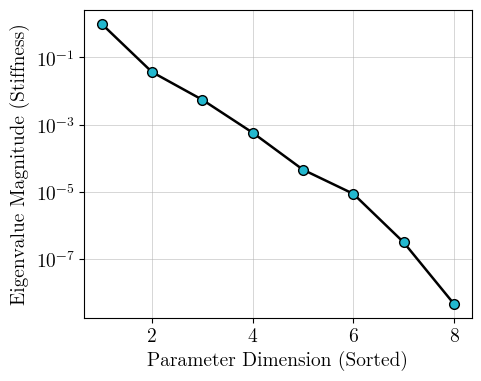

Max Eigenvalue (Stiffest): 1.6838e+03
Min Eigenvalue (Sloppiest): 7.7821e-06
Spread: 2.1636e+08


In [22]:
color_plot = colorsNw["cyan"][5]

normalized_eigenvalues = eigenvalues / eigenvalues[0]

mpl.rcParams.update(mpl.rcParamsDefault)
plt.rc("font", family="Latin Modern Roman")
plt.rc("xtick", labelsize="medium")
plt.rc("ytick", labelsize="medium")
rc = {"mathtext.fontset": "cm"}
plt.rcParams.update(rc)
plt.rcParams["font.serif"] = plt.rcParams["font.serif"]

# Plot the "Sloppy Spectrum"
plt.figure(figsize=(5, 4))
plt.plot(range(1, len(normalized_eigenvalues) + 1), normalized_eigenvalues.numpy(),
        'o-', 
        color='black',
        markerfacecolor=color_plot,
        linewidth=1.8,
        markersize=7)
plt.yscale('log')


ax = plt.gca()
ax.tick_params(axis="both", which="major", labelsize=14)
plt.xlabel("Parameter Dimension (Sorted)", fontsize=14)
plt.ylabel("Eigenvalue Magnitude (Stiffness)", fontsize=14)
plt.grid(True, which="both", linewidth=0.6, alpha=0.6)
plt.show()

# Print the Condition Number (Ratio of stiffest to sloppiest)
condition_number = eigenvalues[0] / eigenvalues[-1]
print(f"Max Eigenvalue (Stiffest): {eigenvalues[0]:.4e}")
print(f"Min Eigenvalue (Sloppiest): {eigenvalues[-1]:.4e}")
print(f"Spread: {condition_number:.4e}")


Training the Micro-MLP to find a minimum...
Final Training Loss: 0.0064
Computing exact 40x40 Hessian...


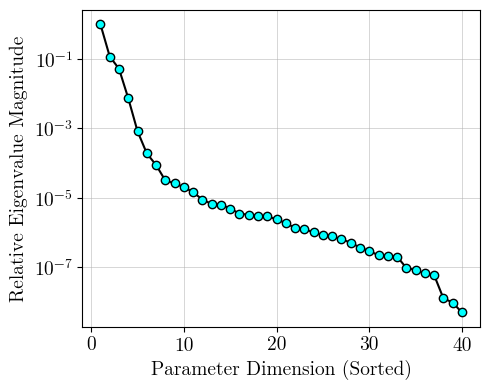

Max Eigenvalue (Stiffest): 9.8316e+01
Min Eigenvalue (Sloppiest): 4.6990e-07
Spread (Condition Number): 2.0923e+08


In [24]:
# Create a simple synthetic dataset (e.g., a noisy sine wave)
torch.manual_seed(42)
X_train = torch.rand(100, 1) * 2 * torch.pi
y_train = torch.sin(X_train) + torch.randn(100, 1) * 0.1

# Define the Micro-MLP Functionally
# Architecture: 1 input -> 13 hidden (Tanh) -> 1 output 
# Total parameters: (1*13 + 13) + (13*1 + 1) = 40 parameters

# ---------------------------------------------------------
# Initialize a single flat tensor for all 40 parameters
params_init = torch.randn(40, dtype=torch.float64) * 0.1
params = torch.nn.Parameter(params_init)

def mlp_forward(flat_params, x):
    """Reconstructs the network from a 1D parameter vector."""
    # Unpack the 1D tensor into weight and bias matrices
    w1 = flat_params[0:13].view(13, 1)
    b1 = flat_params[13:26]
    w2 = flat_params[26:39].view(1, 13)
    b2 = flat_params[39:40]
    
    # Forward pass: Linear -> Tanh -> Linear
    hidden = torch.tanh(F.linear(x.double(), w1, b1))
    out = F.linear(hidden, w2, b2)
    return out

# Train the network to find the local minimum
# (The Hessian is only physically meaningful at the bottom of the error basin)
optimizer = torch.optim.Adam([params], lr=0.05)
print("Training the Micro-MLP to find a minimum...")
for epoch in range(1500):
    optimizer.zero_grad()
    preds = mlp_forward(params, X_train)
    loss = F.mse_loss(preds, y_train.double())
    loss.backward()
    optimizer.step()
print(f"Final Training Loss: {loss.item():.4f}")

# Compute the Exact Hessian and Eigenvalues
def cost_function(flat_params):
    """The function we are taking the second derivative of."""
    preds = mlp_forward(flat_params, X_train)
    return F.mse_loss(preds, y_train.double())

print("Computing exact 40x40 Hessian...")
# Compute exact second derivatives
hessian_matrix = torch.autograd.functional.hessian(cost_function, params)

# Compute eigenvalues of the symmetric Hessian matrix
eigenvalues, _ = torch.linalg.eigh(hessian_matrix)

# Sort descending and take absolute values
eigenvalues = torch.sort(torch.abs(eigenvalues), descending=True).values

# Normalize so the maximum is 1
normalized_eigenvalues = eigenvalues / eigenvalues[0]

# 5. Plot using your LaTeX styling
color_plot = "cyan" 

mpl.rcParams.update(mpl.rcParamsDefault)
plt.rc("font", family="Latin Modern Roman")
plt.rc("xtick", labelsize="medium")
plt.rc("ytick", labelsize="medium")
rc = {"mathtext.fontset": "cm"}
plt.rcParams.update(rc)
plt.rcParams["font.serif"] = plt.rcParams["font.serif"]

plt.figure(figsize=(5, 4))
plt.plot(range(1, len(normalized_eigenvalues) + 1), normalized_eigenvalues.detach().numpy(), 
         'o-', color='black', markerfacecolor=color_plot)
plt.yscale('log')

ax = plt.gca()
ax.tick_params(axis="both", which="major", labelsize=14)
plt.xlabel("Parameter Dimension (Sorted)", fontsize=14)
plt.ylabel("Relative Eigenvalue Magnitude", fontsize=14)
plt.grid(True, which="both", linewidth=0.6, alpha=0.6)
plt.tight_layout()
plt.show()

# Print the Condition Number
condition_number = eigenvalues[0] / eigenvalues[-1]
print(f"Max Eigenvalue (Stiffest): {eigenvalues[0]:.4e}")
print(f"Min Eigenvalue (Sloppiest): {eigenvalues[-1]:.4e}")
print(f"Spread (Condition Number): {condition_number:.4e}")

### Percolation 

In [1]:


def check_percolation(L, p):
    """Returns True if a cluster spans from top to bottom."""
    # 1. Create a random grid
    grid = np.random.rand(L, L) < p
    
    # 2. Label connected clusters (4-connectivity)
    labeled_grid, num_features = label(grid)
    
    # 3. Check if any label in the top row is also in the bottom row
    top_row_labels = set(labeled_grid[0, :])
    bottom_row_labels = set(labeled_grid[-1, :])
    
    # Remove background (0) from sets
    top_row_labels.discard(0)
    
    # Intersection tells us if a path exists
    common = top_row_labels.intersection(bottom_row_labels)
    return len(common) > 0

# Test a single run
L = 50
p = 0.5920 # Near pc for square site percolation
is_percolating = check_percolation(L, p)
print(f"L={L}, p={p} | Percolates: {is_percolating}")

NameError: name 'np' is not defined

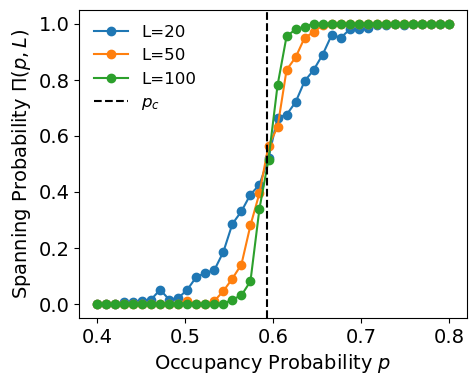

In [7]:
L_values = [20, 50, 100] # Different system sizes
p_values = np.linspace(0.4, 0.8, 40)
n_trials = 200

results = {}

for L in L_values:
    probs = []
    for p in p_values:
        successes = sum(check_percolation(L, p) for _ in range(n_trials))
        probs.append(successes / n_trials)
    results[L] = probs

# Plotting the raw data
plt.figure(figsize=(5, 4))
ax = plt.gca()
ax.tick_params(axis="both", which="major", labelsize=14)

for L, probs in results.items():
    plt.plot(p_values, probs, 'o-', label=f"L={L}")
plt.axvline(0.5927, color='k', linestyle='--', label="$p_c$")
plt.xlabel(r"Occupancy Probability $p$", fontsize=14)
plt.ylabel(r"Spanning Probability $\Pi(p,L)$", fontsize=14)
plt.legend(frameon=False,fontsize=12)
plt.show()

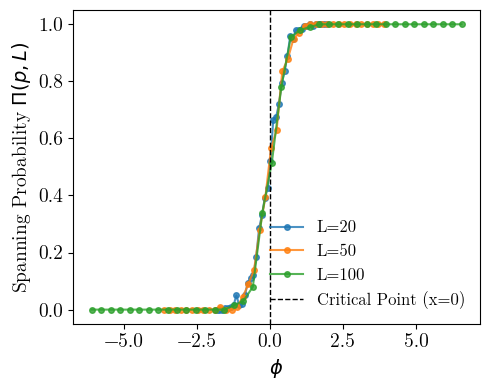

In [ ]:
# --- Physical Constants for 2D Site Percolation ---
pc = 0.5927  # Theoretical critical threshold
nu = 4/3     # Theoretical critical exponent
scaling_exp = 1/nu # = 0.75

# --- Plotting Setup (Using your preferred style) ---
plt.figure(figsize=(5, 4))
plt.rc("font", family="Latin Modern Roman")

# Assuming 'results' is a dictionary from the previous run: {L: [probs...]}
# And 'p_values' is the array of probabilities tested.

for L, probs in results.items():
    # Transform the x-axis: (p - pc) * L^(1/nu)
    scaled_x = (p_values - pc) * (L ** scaling_exp)
    
    
    # Plot the scaled data
    plt.plot(scaled_x, probs, 'o-', label=f"L={L}", markersize=4, alpha=0.8)

# Formatting the "Master Curve"
ax = plt.gca()
ax.tick_params(axis="both", which="major", labelsize=14)

plt.axvline(0, color='black', linestyle='--', linewidth=1, label="Critical Point (x=0)")
plt.xlabel(r"$\phi$", fontsize=14)
plt.ylabel(r"Spanning Probability $\Pi(p,L)$", fontsize=14)
# plt.title("Data Collapse: The Universal Scaling Function", fontsize=16)
# plt.grid(True, which="both", linewidth=0.5, alpha=0.5)
plt.legend(frameon=False,fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# data = np.load("/home/vishnu/git-test/lama/lama_rand_mask_128/lama_random_mask_nat01.npz", allow_pickle=True)
# data = np.load("/home/vishnu/git-test/lama/lama_rand_mask_128/lama_random_mask_nat02.npz", allow_pickle=True)
# data = np.load("/home/vishnu/git-test/lama/lama_rand_mask_128/lama_random_mask_CheckerBoard.npz", allow_pickle=True)
data = np.load("/home/vishnu/git-test/lama/lama_rand_mask_128/lama_random_mask_1.npz", allow_pickle=True)
# data = np.load("lama_CheckerBoard.npz", allow_pickle=True)

n_values = data["n_values"]
mean_err = data["mean_err"]
var_err = data["var_err"]
all_errors = data["all_errors"].item()

df = pd.DataFrame({
    "n": n_values,
    "fraction": n_values / (128*128),
    "mean_mse": mean_err,
    "var_mse": var_err
})

In [17]:
H, W = 128, 128
phi = df["n"] / (H * W)

small_phi_mask = phi < 0.01   # adjust threshold
selected_n = df["n"][small_phi_mask]
selected_n.head(10)

0      1
1      2
2      7
3     13
4     23
5     35
6     51
7     69
8     89
9    113
Name: n, dtype: int64

In [ ]:
alpha_list = []
phi_list = []

for n in selected_n:

    errs = all_errors[n]

    # center (important for stable fitting)
    errs = errs - np.mean(errs)

    try:
        alpha, beta, loc, scale = levy_stable.fit(errs)

        alpha_list.append(alpha)
        phi_list.append(n / (H * W))

        print(f"phi={n/(H*W):.5f}, alpha={alpha:.3f}")

    except Exception as e:
        print(f"Fit failed for n={n}: {e}")

In [ ]:
plt.figure(figsize=(5,4))

plt.plot(phi_list, alpha_list, "-o")

plt.xlabel(r"$\phi$")
plt.ylabel(r"$\alpha$ (Lévy exponent)")

plt.grid(True, which="major", linewidth=0.6, alpha=0.6)
plt.tight_layout()
plt.show()